# Perceptrons

Perceptrons são a base de muitos modelos de aprendizado de máquina. Eles consistem em um conjunto de entradas, um conjunto de pesos e uma função de ativação. O perceptron recebe um conjunto de entradas, multiplica cada entrada por seu peso e passa a soma total através da função de ativação para obter uma saída ou previsão.

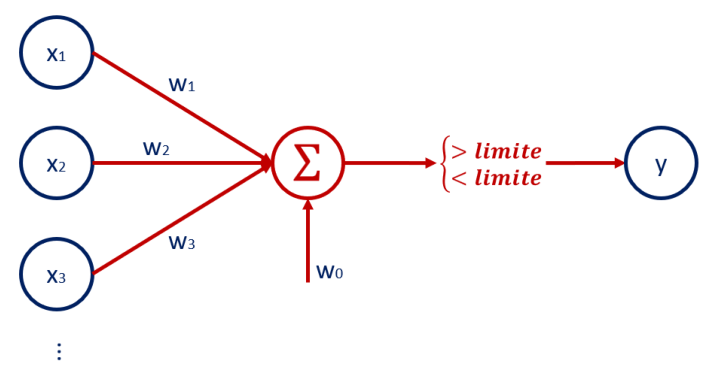

Matematicamente, a operação de um perceptron pode ser descrita da seguinte maneira:

1. **Combinação Linear**:
   A entrada para o perceptron é uma combinação linear dos valores de entrada ($x$) e pesos associados ($w$), junto com um viés ($b$):

$$ z = \sum_{i=1}^n w_i x_i + b $$

onde:
   - $ n $ é o número de entradas,
   - $ w_i $ é o peso associado à $i$-ésima entrada,
   - $ x_i $ é o valor da $i$-ésima entrada,
   - $ b $ é o viés.

2. **Função de Ativação**:

Uma função de ativação é uma função matemática que transforma o valor de saída.

   A saída do perceptron é então obtida aplicando uma função de ativação ($ \phi $) à combinação linear:

$$ y = \phi(z) $$

A função de ativação mais comum usada em um perceptron simples é a função degrau, que pode ser escrita como:

$$ \phi(z) = 
  \begin{cases} 
    1 & \text{se } z \geq 0 \\
    0 & \text{se } z < 0 
  \end{cases}
$$

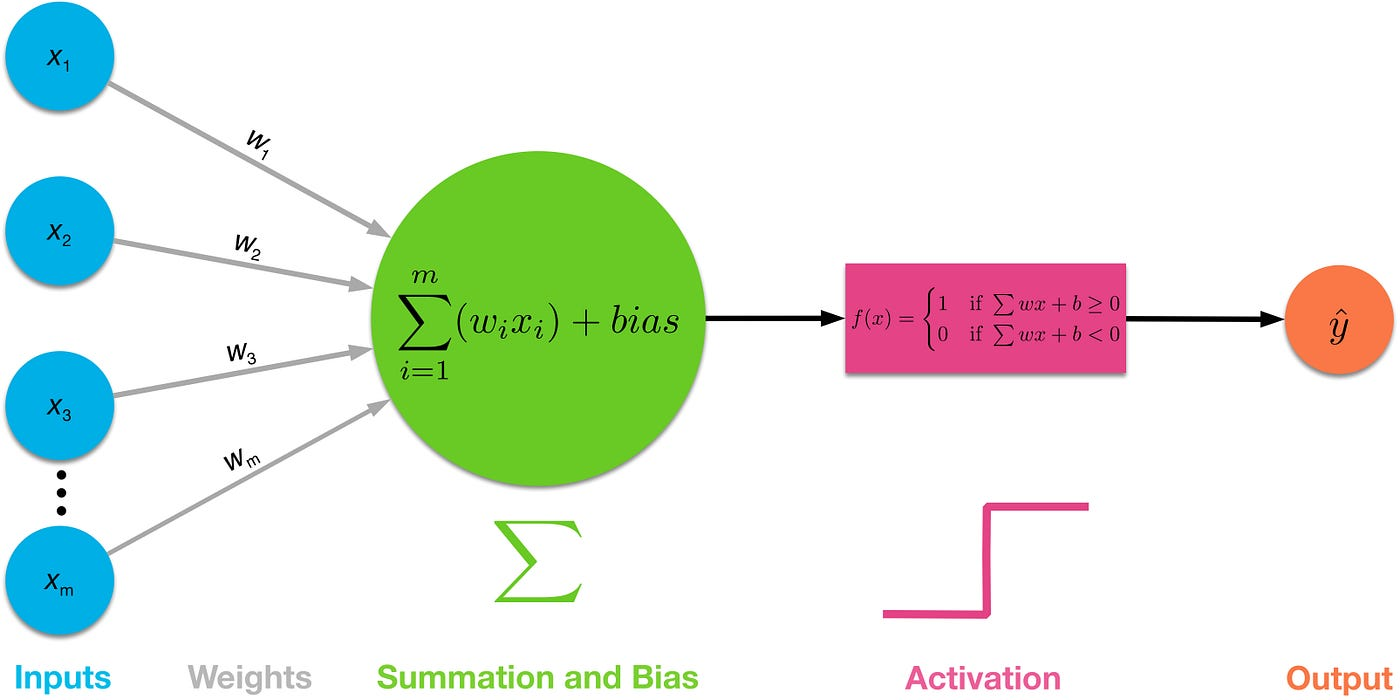


3. **Regra de Aprendizado**:
   A atualização dos pesos em um perceptron é feita de acordo com a seguinte regra, onde $ \nu $ é a taxa de aprendizado:

$$ w_i^{(n+1)} = w_i^{(n)} + \nu (y - \hat{y}) x_i $$

onde:
   - $ w_i^{(n)} $ é o peso da $i$-ésima entrada no $n$-ésimo passo,
   - $ y $ é o rótulo real,
   - $ \hat{y} $ é a saída prevista do perceptron,
   - $ x_i $ é o valor da $i$-ésima entrada.


## Um exemplo simples

In [1]:
import matplotlib.pyplot as plt
import numpy as np

COLORMAP = "coolwarm"

In [2]:
X = np.array([[2.5, 2.5], [4, -1], [1, -4], [-3, 1.25], [-2, -4], [1, 5]])
y = np.array([1, 1, 1, 0, 0, 0])

In [3]:
X

array([[ 2.5 ,  2.5 ],
       [ 4.  , -1.  ],
       [ 1.  , -4.  ],
       [-3.  ,  1.25],
       [-2.  , -4.  ],
       [ 1.  ,  5.  ]])

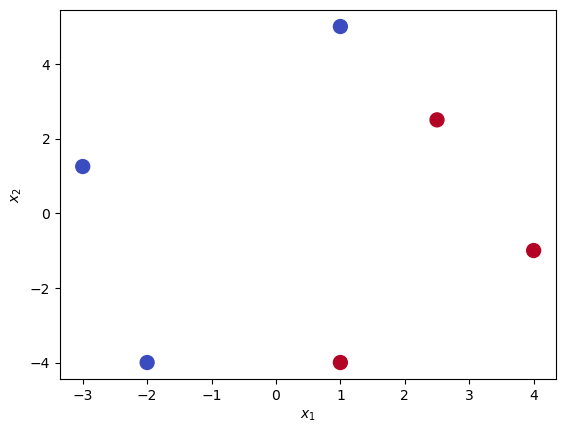

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, cmap=COLORMAP)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.show()

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html

In [5]:
from sklearn.linear_model import Perceptron

clf = Perceptron()

clf.fit(X, y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [6]:
clf.coef_

array([[ 9.5, -1.5]])

In [7]:
clf.intercept_

array([-4.])

In [8]:
clf.classes_

array([0, 1])

In [9]:
clf.predict([[-2, 2]])

array([0])

In [10]:
clf.predict([[3, 2]])

array([1])

In [11]:
clf.decision_function(X)

array([ 16.   ,  35.5  ,  11.5  , -34.375, -17.   ,  -2.   ])

In [12]:
decision_function = clf.decision_function(X)  # z

decision_function

array([ 16.   ,  35.5  ,  11.5  , -34.375, -17.   ,  -2.   ])

### Função de ativação sigmoid

A função de ativação sigmoid é uma função matemática que recebe um número real e retorna outro número real entre 0 e 1. Essa propriedade a torna útil em problemas de classificação binária. É uma função não linear usada em modelos de aprendizado de máquina para introduzir não linearidade nas saídas de um modelo. A função de ativação sigmoid é definida como:

$$ \phi(z) = \frac{1}{1 + e^{-z}} $$

onde $z$ é a combinação linear das entradas e pesos:

$$ z = \sum_{i=1}^n w_i x_i + b $$


In [20]:
def funcao_sigmoid(z):
    return 1 / (1 + np.exp(-z))

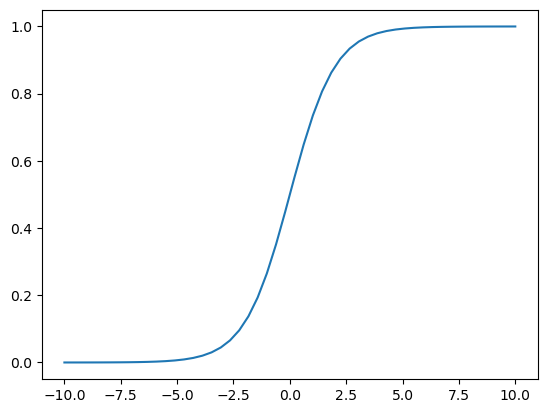

In [21]:
valores = np.linspace(-10, 10)
plt.plot(valores, funcao_sigmoid(valores))

plt.show()

https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html

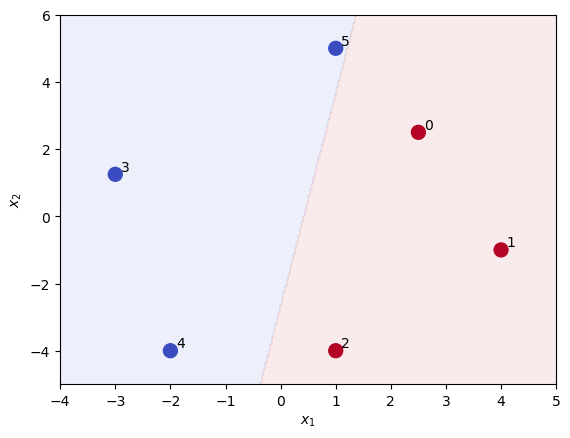

In [13]:
from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(clf, X, response_method="predict", cmap=COLORMAP, grid_resolution=300, alpha=0.1)

disp.ax_.scatter(X[:, 0], X[:, 1], c=y, cmap=COLORMAP, s=100)

disp.ax_.set_xlabel("$x_1$")
disp.ax_.set_ylabel("$x_2$")

for i, x in enumerate(X):
    plt.annotate(i, (x[0] + 0.1, x[1] + 0.1))

plt.show()

In [14]:
clf.predict(X)

array([1, 1, 1, 0, 0, 0])

In [15]:
decision_function

array([ 16.   ,  35.5  ,  11.5  , -34.375, -17.   ,  -2.   ])

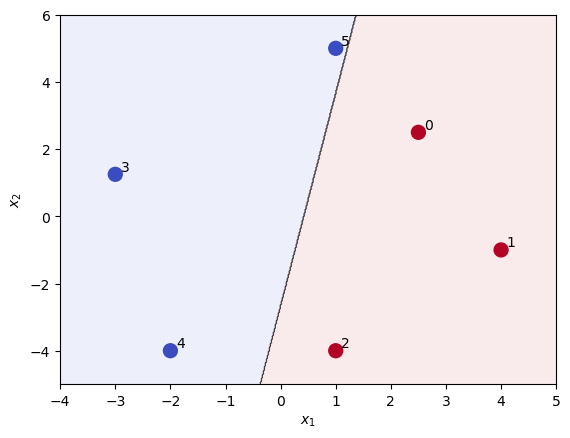

In [16]:
fig, ax = plt.subplots()

disp1 = DecisionBoundaryDisplay.from_estimator(
    clf, 
    X, 
    response_method="predict", 
    cmap=COLORMAP, 
    grid_resolution=300, 
    alpha=0.1,
    ax=ax
)

disp2 = DecisionBoundaryDisplay.from_estimator(
    clf, 
    X, 
    response_method="predict", 
    grid_resolution=500, 
    alpha=0.5,
    ax=ax,
    plot_method="contour",
    colors="black",
    linewidths=0.25,
)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=COLORMAP, s=100)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

for i, x in enumerate(X):
    plt.annotate(i, (x[0] + 0.1, x[1] + 0.1))

plt.show()

In [17]:
decision_function

array([ 16.   ,  35.5  ,  11.5  , -34.375, -17.   ,  -2.   ])

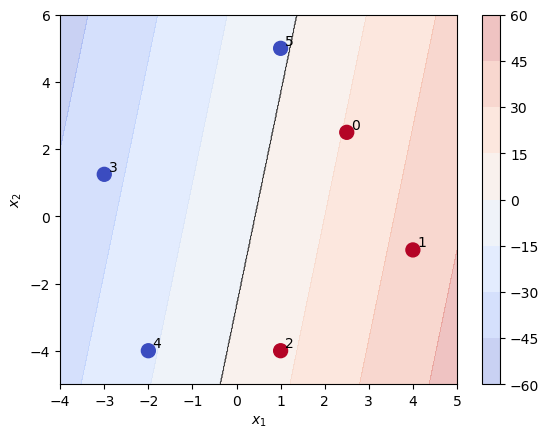

In [18]:
fig, ax = plt.subplots()

disp1 = DecisionBoundaryDisplay.from_estimator(
    clf, 
    X, 
    response_method="decision_function", 
    cmap=COLORMAP, 
    grid_resolution=300, 
    alpha=0.3,
    ax=ax
)

disp2 = DecisionBoundaryDisplay.from_estimator(
    clf, 
    X, 
    response_method="predict", 
    grid_resolution=500, 
    alpha=0.5,
    ax=ax,
    plot_method="contour",
    colors="black",
    linewidths=0.25,
)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=COLORMAP, s=100)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

for i, x in enumerate(X):
    plt.annotate(i, (x[0] + 0.1, x[1] + 0.1))

fig.colorbar(disp1.surface_, ax=ax)

plt.show()

In [19]:
decision_function

array([ 16.   ,  35.5  ,  11.5  , -34.375, -17.   ,  -2.   ])